In [ ]:
# 1. download this file and .zip of cinic10 locally
# 2. put .zip on google drive in the main folder (MyDrive)
# 3. open google colab and just open this file, just select from local files, no connecting to github or whatever (you must be logged in the same google account as the drive)
# 4. when running the next cell give drive or google access to everything

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip /content/drive/MyDrive/cinic10zip.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/valid/truck/n03632852_1173.png  
  inflating: /content/data/valid/truck/n03632852_11766.png  
  inflating: /content/data/valid/truck/n03632852_11887.png  
  inflating: /content/data/valid/truck/n03632852_1191.png  
  inflating: /content/data/valid/truck/n03632852_1192.png  
  inflating: /content/data/valid/truck/n03632852_1195.png  
  inflating: /content/data/valid/truck/n03632852_1207.png  
  inflating: /content/data/valid/truck/n03632852_12128.png  
  inflating: /content/data/valid/truck/n03632852_1214.png  
  inflating: /content/data/valid/truck/n03632852_1237.png  
  inflating: /content/data/valid/truck/n03632852_1248.png  
  inflating: /content/data/valid/truck/n03632852_1261.png  
  inflating: /content/data/valid/truck/n03632852_1264.png  
  inflating: /content/data/valid/truck/n03632852_1292.png  
  inflating: /content/data/valid/truck/n03632852_1313.png  
  inflating: /content/data/valid/truck/n036328

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
import random
import time
import os
import torchvision
import matplotlib.pyplot as plt

In [3]:
# reproducibility

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    except Exception as e:
        pass


    print(f"full reproducibility with seed set at: {seed}")

!seed_everything(420)

/bin/bash: -c: line 1: syntax error near unexpected token `420'
/bin/bash: -c: line 1: `seed_everything(420)'


In [10]:
cinic_directory = './data/'
cinic_mean = [0.47889522, 0.47227842, 0.43047404]
cinic_std = [0.24205776, 0.23828046, 0.25874835]
cinic_train = torch.utils.data.DataLoader(
    torchvision.datasets.ImageFolder(cinic_directory + '/train',
        transform=torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=cinic_mean,std=cinic_std)])),
    batch_size=128, shuffle=True)

In [12]:
images, labels = next(iter(cinic_train))

print(f"shape of images batch: {images.shape}")
print(f"labels shape: {labels.shape}")

shape of images batch: torch.Size([128, 3, 32, 32])
labels shape: torch.Size([128])


image classes: ['frog', 'frog', 'bird', 'automobile', 'truck']


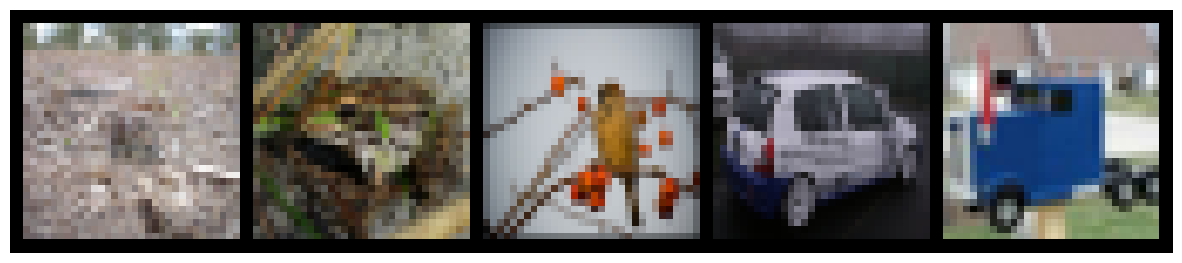

In [18]:
images, labels = next(iter(cinic_train))

top_5_images = images[:5]

mean = torch.tensor(cinic_mean).view(3, 1, 1)
std = torch.tensor(cinic_std).view(3, 1, 1)
top_5_images = top_5_images * std + mean

grid = torchvision.utils.make_grid(top_5_images, nrow=5)

plt.figure(figsize=(15, 5))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis('off')

classes = cinic_train.dataset.classes
titles = [classes[labels[i]] for i in range(5)]
print("image classes:", titles)

plt.show()